# Vol 28 — Credit Desk — CDS, CDO, Correlation, CreditMetrics

**問い:** Hull Ch.24–25 の印刷された数値例を、検証済みコードで再現できるか（本巻で実装しない節は notebook 末尾に明記）。

> **核心** — 複雑なモデルは必ず単純baselineとhard checkに並べる。<br>
> **直感** — 平均誤差だけでは、尾部・裁定・cash-flow破綻を隠せる。<br>
> **実務** — 再現可能なartifactと明示的な失敗条件をmodel risk管理の単位にする。

## モデルladderと責務

vol.09 が説明文で済ませた節を節単位で埋める。債券価格と CDS 気配からの区分定数ハザード（Ex 24.1/24.2）、Table 25.2–25.4 の CDS レッグと MTM、Ex 25.1 の固定クーポン価格、Black 型 CDS オプション、Gauss–Hermite 求積による合成 CDO（Ex 25.2）と k-th-to-default（Ex 25.3）、Table 25.6 の iTraxx 気配から Table 25.8 のコンパウンド/ベース相関、double-t コピュラと不均質再帰（§25.11）、Table 24.4 の CreditMetrics 閾値と相関付き格付推移 MC、§24.7 のネッティング・担保・式 (24.5)。すべて Hull の離散化（期末払い・期中デフォルト）に合わせ、印刷値に ±許容で固定する。

## Artifact契約とdata policy

このnotebookはcommitted JSON/NPZだけを読み、学習・download・GPU検出を行わない。

In [1]:
from pathlib import Path
import hashlib, json
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib  # noqa: F401  (Japanese glyphs in figure labels)

reference = Path('reference')
manifest = json.loads((reference / 'metrics.json').read_text(encoding='utf-8'))
artifact = reference / 'credit_scenarios.npz'
digest = hashlib.sha256(artifact.read_bytes()).hexdigest()
assert manifest['schema_version'] == 1 and manifest['volume'] == 28
assert manifest['data_policy'] == 'synthetic-offline'
assert manifest['companions'][artifact.name] == digest
archive = np.load(artifact, allow_pickle=False)
schema = manifest['companion_schemas'][artifact.name]
assert set(schema) == set(archive.files)
for name in archive.files:
    assert schema[name]['shape'] == list(archive[name].shape)
    assert schema[name]['dtype'] == str(archive[name].dtype)
    assert schema[name]['unit']
artifact_data = {name: archive[name] for name in archive.files}
archive.close()
data = dict(artifact_data)
print(f"schema={manifest['schema_version']} volume={manifest['volume']} digest={digest[:16]} arrays={len(artifact_data)}")

schema=1 volume=28 digest=ffadce77b7a61b87 arrays=88


## 指標の要約

指標は同じsynthetic fixture・単位・seedで比較する。

In [2]:
for key, value in manifest['metrics'].items():
    print(f'{key}: {value}')

base_correlation_max_reprice_error: 3.737895409861025e-15
binary_cds_spread_bp: 205.00429358998645
bond_bootstrap_hazard_1: 0.024575329948416012
bond_bootstrap_hazard_2: 0.03475777894122982
bond_bootstrap_hazard_3: 0.037351228053560705
cdo_index_hazard: 0.008296995340469394
cdo_maturity: 5.0
cdo_mezz_accrual: 0.01869664988180446
cdo_mezz_annuity: 4.28464661505203
cdo_mezz_protection: 0.14957319905443567
cdo_mezz_spread_bp: 347.5744086539548
cdo_names: 125
cdo_rate: 0.035
cdo_rho: 0.15
cds_bootstrap_freq: 4
cds_bootstrap_max_reprice_error: 4.388850394221322e-16
cds_hazard: 0.02
cds_implied_hazard_100bp: 0.016258868561856883
cds_mtm_seller_150bp: 0.011109406541533029
cds_par_spread_bp: 123.00257615399185
cds_protection_pv: 0.050615408045779915
cds_rate: 0.05
cds_risky_duration: 4.114987639154196
credit_var_correlated: 6.599999999999999
credit_var_independent: 3.0
creditmetrics_bbb_default_threshold: 2.9290497489376195
creditmetrics_rho: 0.2
cva_general_equivalent: 0.24458895909902348
cva

## Acceptance scope

この判定はintegrationと再現性だけを対象とし、市場適合・予測力・production readinessを承認しない。

In [3]:
assert manifest['acceptance']['scope'] == 'integration_and_reproducibility'
assert manifest['acceptance']['model_performance_approved'] is False
assert manifest['acceptance']['passed'] is True
for check in manifest['acceptance']['checks']:
    print(('PASS' if check['passed'] else 'FAIL'), check['name'], check['observed'], check['criterion'])

PASS cds_par_spread_hull_pin 123.00257615399185 survival/DF/PV columns recomputed from λ, r, R match the committed columns (1e-12); Σpayoff/(Σpayment+Σaccrual) within 0.5 bp of Hull's 123 bp and 1e-9 bp of the metric
PASS cds_mtm_identity 0.011109406541533029 D·0.015 − protection equals the stored metric and the grid value (1e-10) and Hull's 0.0111 (1e-4)
PASS cds_bootstrap_round_trip 4.388850394221322e-16 par spreads rebuilt from the committed hazards reprice the quotes (1e-10) and match the stored repricing (1e-12)
PASS bond_bootstrap_hull_pin 0.0019938056124146897 hazards within 0.0002 of 2.46/3.48/3.74% and loss PVs within 0.01 of 1.50/3.53/5.61
PASS fixed_coupon_price_identity 100.2705504281483 D rebuilt from the implied hazard matches the metric (1e-12) and reprices the quote (1e-10); 100 − 100·D·(s−c) equals the stored price (1e-10) and Hull's 100.27 (0.01)
PASS cds_option_parity 1.3877787807814457e-17 F and A rebuilt from the hazard curve match the metrics (1e-12), Black values

## 債券価格ブートストラップ vs Hull Ex 24.2

単一のaggregate scoreではなく、構造別・時間別・stress別に読む。

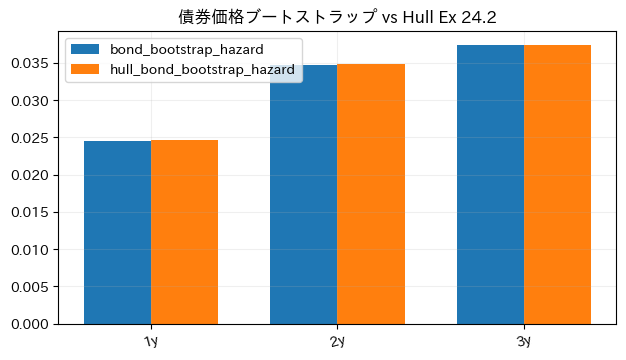

In [4]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.set_title("債券価格ブートストラップ vs Hull Ex 24.2")
x = np.arange(len(data["bond_maturity_label"]))
ax.bar(x - .18, data["bond_bootstrap_hazard"], width=.36, label="bond_bootstrap_hazard")
ax.bar(x + .18, data["hull_bond_bootstrap_hazard"], width=.36, label="hull_bond_bootstrap_hazard")
ax.set_xticks(x, data["bond_maturity_label"], rotation=15)
ax.legend()
ax.grid(alpha=.2)
plt.show()

## CDS レッグの年別 PV（Table 25.3 vs 25.4）

単一のaggregate scoreではなく、構造別・時間別・stress別に読む。

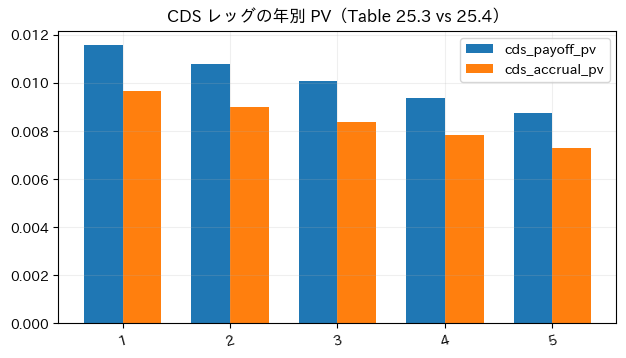

In [5]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.set_title("CDS レッグの年別 PV（Table 25.3 vs 25.4）")
x = np.arange(len(data["cds_year_label"]))
ax.bar(x - .18, data["cds_payoff_pv"], width=.36, label="cds_payoff_pv")
ax.bar(x + .18, data["cds_accrual_pv"], width=.36, label="cds_accrual_pv")
ax.set_xticks(x, data["cds_year_label"], rotation=15)
ax.legend()
ax.grid(alpha=.2)
plt.show()

## 契約スプレッド別の売り手 MTM（150bp で 0.0111）

単一のaggregate scoreではなく、構造別・時間別・stress別に読む。

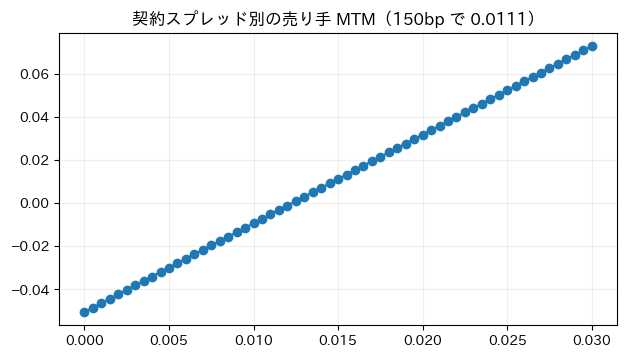

In [6]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.set_title("契約スプレッド別の売り手 MTM（150bp で 0.0111）")
ax.plot(data["cds_contract_spread_grid"], data["cds_mtm_seller"], marker="o")
ax.grid(alpha=.2)
plt.show()

## 固定クーポン 40bp のアップフロント価格 vs 気配（Ex 25.1）

単一のaggregate scoreではなく、構造別・時間別・stress別に読む。

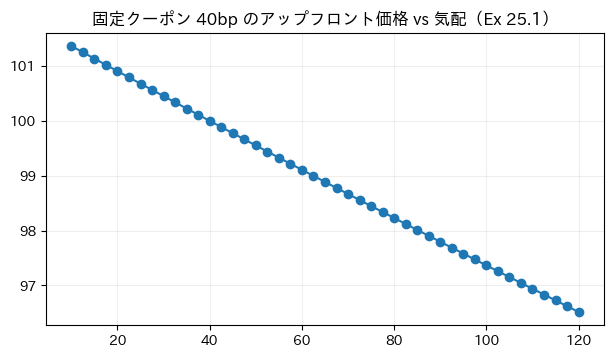

In [7]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.set_title("固定クーポン 40bp のアップフロント価格 vs 気配（Ex 25.1）")
ax.plot(data["index_quote_grid"], data["fixed_coupon_price_grid"], marker="o")
ax.grid(alpha=.2)
plt.show()

## CDS オプション payer / receiver（Black 型）

単一のaggregate scoreではなく、構造別・時間別・stress別に読む。

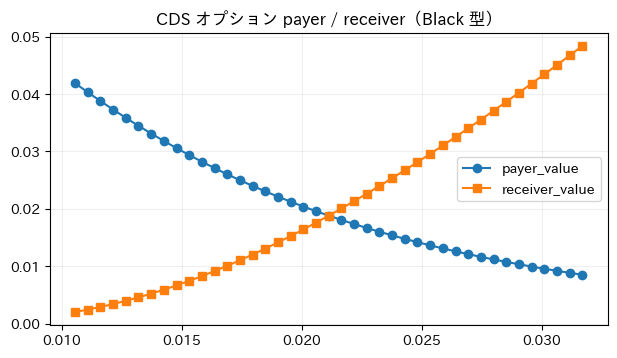

In [8]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.set_title("CDS オプション payer / receiver（Black 型）")
ax.plot(data["option_strike_grid"], data["payer_value"], marker="o", label="payer_value")
ax.plot(data["option_strike_grid"], data["receiver_value"], marker="s", label="receiver_value")
ax.legend()
ax.grid(alpha=.2)
plt.show()

## メザニン期待元本 E_j(F_k)（Table 25.7）

単一のaggregate scoreではなく、構造別・時間別・stress別に読む。

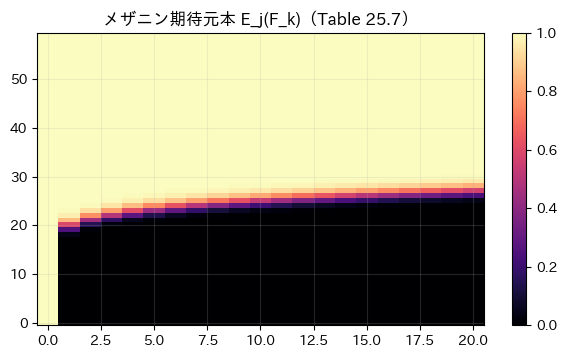

In [9]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.set_title("メザニン期待元本 E_j(F_k)（Table 25.7）")
im = ax.imshow(data["tranche_expected_principal"], aspect="auto", origin="lower", cmap="magma")
fig.colorbar(im, ax=ax)
ax.grid(alpha=.2)
plt.show()

## 標準トランシェのブレークイーブンスプレッド vs ρ

単一のaggregate scoreではなく、構造別・時間別・stress別に読む。

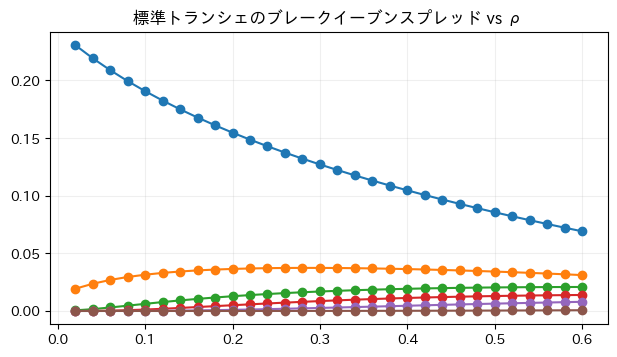

In [10]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.set_title("標準トランシェのブレークイーブンスプレッド vs ρ")
ax.plot(data["rho_grid"], data["tranche_spread_vs_rho"], marker="o")
ax.grid(alpha=.2)
plt.show()

## k-th-to-default スプレッド（Ex 25.3 は k=3）

単一のaggregate scoreではなく、構造別・時間別・stress別に読む。

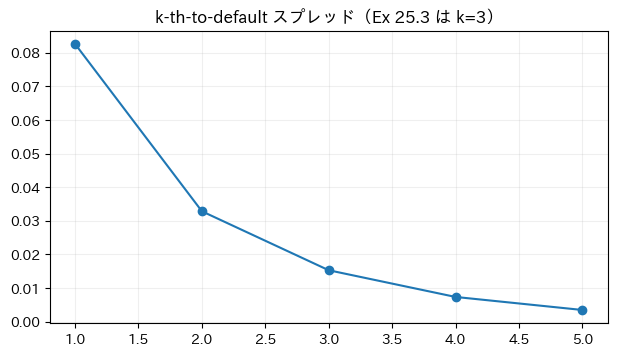

In [11]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.set_title("k-th-to-default スプレッド（Ex 25.3 は k=3）")
ax.plot(data["kth_order"], data["kth_spread"], marker="o")
ax.grid(alpha=.2)
plt.show()

## Table 25.8：コンパウンド vs ベース相関

単一のaggregate scoreではなく、構造別・時間別・stress別に読む。

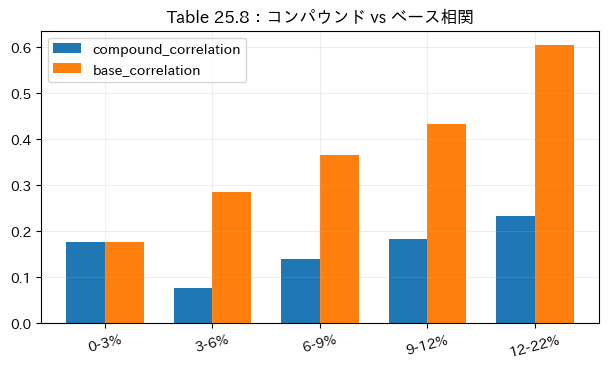

In [12]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.set_title("Table 25.8：コンパウンド vs ベース相関")
x = np.arange(len(data["market_tranche_label"]))
ax.bar(x - .18, data["compound_correlation"], width=.36, label="compound_correlation")
ax.bar(x + .18, data["base_correlation"], width=.36, label="base_correlation")
ax.set_xticks(x, data["market_tranche_label"], rotation=15)
ax.legend()
ax.grid(alpha=.2)
plt.show()

## 0–X% 期待損失 PV（Figure 25.3）

単一のaggregate scoreではなく、構造別・時間別・stress別に読む。

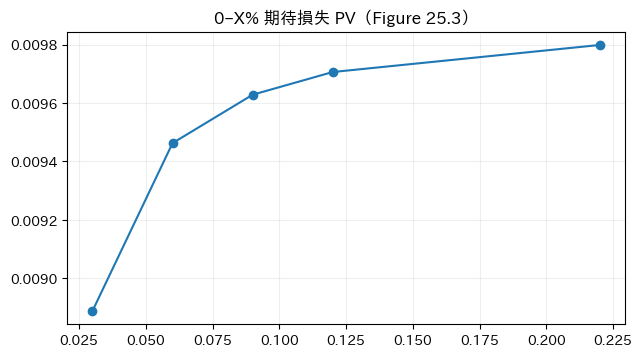

In [13]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.set_title("0–X% 期待損失 PV（Figure 25.3）")
ax.plot(data["el_curve_x"], data["el_curve_value"], marker="o")
ax.grid(alpha=.2)
plt.show()

## double-t コピュラのメザニンスプレッド vs ν

単一のaggregate scoreではなく、構造別・時間別・stress別に読む。

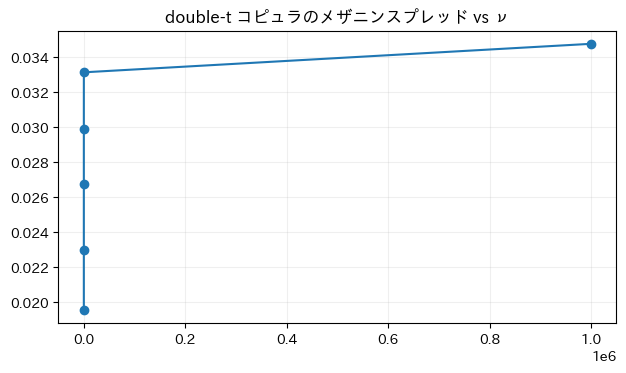

In [14]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.set_title("double-t コピュラのメザニンスプレッド vs ν")
ax.plot(data["double_t_nu_grid"], data["double_t_spread"], marker="o")
ax.grid(alpha=.2)
plt.show()

## CreditMetrics 閾値：AAA vs BBB（Table 24.4、生存格付間の 6 境界）

単一のaggregate scoreではなく、構造別・時間別・stress別に読む。

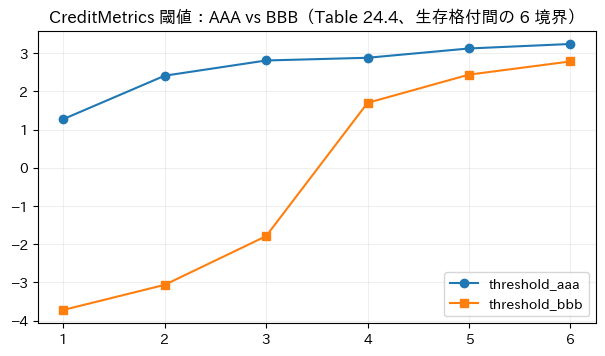

In [15]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.set_title("CreditMetrics 閾値：AAA vs BBB（Table 24.4、生存格付間の 6 境界）")
ax.plot(data["threshold_index"], data["threshold_aaa"], marker="o", label="threshold_aaa")
ax.plot(data["threshold_index"], data["threshold_bbb"], marker="s", label="threshold_bbb")
ax.legend()
ax.grid(alpha=.2)
plt.show()

## 信用損失分布：独立 vs ρ=0.2

単一のaggregate scoreではなく、構造別・時間別・stress別に読む。

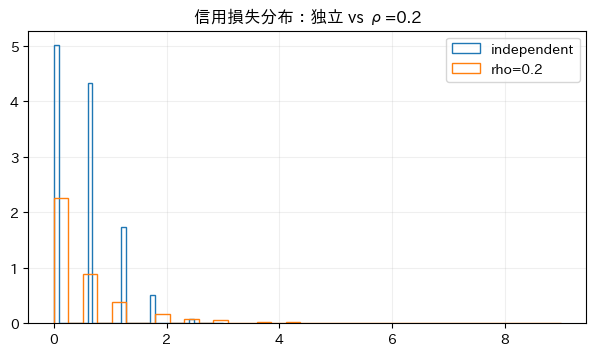

In [16]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.set_title("信用損失分布：独立 vs ρ=0.2")
for i, label in enumerate(data["credit_loss_names"]):
    ax.hist(data["credit_loss_by_case"][i], bins=35, density=True, histtype="step", label=str(label))
ax.legend()
ax.grid(alpha=.2)
plt.show()

## 担保付きエクスポージャ：Ex 24.4 の 4 ケース

単一のaggregate scoreではなく、構造別・時間別・stress別に読む。

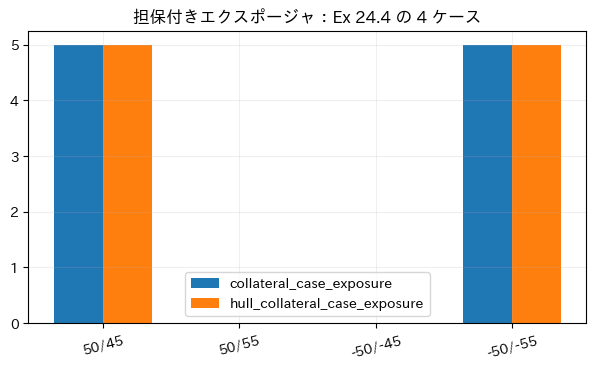

In [17]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.set_title("担保付きエクスポージャ：Ex 24.4 の 4 ケース")
x = np.arange(len(data["collateral_case_label"]))
ax.bar(x - .18, data["collateral_case_exposure"], width=.36, label="collateral_case_exposure")
ax.bar(x + .18, data["hull_collateral_case_exposure"], width=.36, label="hull_collateral_case_exposure")
ax.set_xticks(x, data["collateral_case_label"], rotation=15)
ax.legend()
ax.grid(alpha=.2)
plt.show()

## Artifact恒等式の再計算検証

acceptance identityをcommitted artifactから直接recomputeし、JSONのフラグに依存せず主要な数値恒等式を確認する。

In [18]:
m = manifest['metrics']
spread_bp = data['cds_payoff_pv'].sum() / (data['cds_payment_pv'].sum() + data['cds_accrual_pv'].sum()) * 1e4
assert abs(spread_bp - 123.0) <= 0.5 and abs(spread_bp - m['cds_par_spread_bp']) <= 1e-9
times = data['tranche_payment_time']; prev = np.concatenate([[0.0], times[:-1]]); w = data['factor_weight']
E = data['tranche_expected_principal']; dt = times - prev; r = m['cdo_rate']
loss = E[:, :-1] - E[:, 1:]
A = w @ (dt * E[:, 1:] * np.exp(-r * times)).sum(axis=1)
B = w @ (0.5 * dt * loss * np.exp(-r * 0.5 * (times + prev))).sum(axis=1)
C = w @ (loss * np.exp(-r * 0.5 * (times + prev))).sum(axis=1)
assert abs(C / (A + B) * 1e4 - 348.0) <= 1.0
widths = data['capital_structure_detach'] - data['capital_structure_attach']
assert abs(widths @ data['capital_structure_expected_loss'] - m['portfolio_expected_loss']) <= 1e-8
assert np.all(np.diff(data['kth_spread']) < 0)
slopes = np.diff(data['el_curve_value']) / np.diff(data['el_curve_x'])
assert np.all(np.diff(data['el_curve_value']) > 0) and np.all(np.diff(slopes) < 0)
assert np.max(np.abs(data['compound_correlation'] - data['hull_compound_correlation'])) <= 0.01
assert np.max(np.abs(data['base_correlation'] - data['hull_base_correlation'])) <= 0.01
assert np.allclose(data['collateral_case_exposure'], [5, 0, 0, 5])
print('PASS: 123bp / 348bp / 153bp / Table 25.8 / loss conservation / Ex 24.4 recomputed from the artifact')

PASS: 123bp / 348bp / 153bp / Table 25.8 / loss conservation / Ex 24.4 recomputed from the artifact


## 練習問題

1. Table 25.2–25.4 の設定で支払いを四半期にしたとき、パースプレッドはどちらへ動くか。`cds_payment_pv` の構造から予想し、理由をアクルーアルの扱いで説明せよ。
2. `cds_mtm_seller` の傾きは何に等しいか。150bp の MTM 0.0111 と D=4.1150 から確かめよ。
3. Table 25.7 の列 F=−1.0104 で E_20 が 0.5648 まで落ちる理由を、条件付きデフォルト確率 Q(t|F) の式で説明せよ。
4. `tranche_spread_vs_rho` でエクイティのスプレッドが ρ とともに下がり、シニアが上がるのはなぜか。`capital_structure_expected_loss` の合計が ρ に依存しないことと整合させよ。
5. Table 25.8 でコンパウンド相関はスマイル、ベース相関はスキューになる。ガウシアンコピュラが市場と整合しているなら両者はどうなるはずか。`el_curve_value` の傾き ΔEL/ΔX が単調減少することはどの無裁定条件に対応するか。

## 本巻で実装しない節（§24.6 脚注・§25.11）

Hull が数値例を載せていない、または非公開データに依存する項目。コードは持たず、Hull の説明と本巻の実装との関係だけを置く。

- **KMV EDF（§24.6 脚注 11）**：Merton モデルが出すデフォルト確率はリスク中立確率。Moody's KMV はそれを実世界のデフォルト確率（expected default frequency, EDF）へ変換するサービスを提供しているが、変換に使うデータは公開されていない。本巻で計算できるのは `hullkit.credit.merton_default_prob` のリスク中立確率までで、EDF は再現できない。
- **ランダム回収率とランダムファクター負荷（Andersen–Sidenius）**：式 (25.5) のコピュラ相関 ρ をファクター F の関数にし（F が小さい、つまりデフォルト率が高い状態ほど ρ が大きい）、回収率をデフォルト率と負に連動させる。Hull は、この拡張が標準モデルより市場気配によく当てはまると紹介するが、数値例はない。本巻の条件付き求積（`credit_portfolio`）は ρ と R を定数として扱う。
- **implied copula（Hull–White）**：ポートフォリオの全企業に共通の平均ハザードレートが CDO の期間中一定だと仮定し、その確率分布をトランシェ価格から逆算する。第 20 章でオプション価格から株価のインプライド分布を求めるのと同じ考え方。本巻の API はパラメータから価格を出す求積で、分布を推定する最適化は含まない。
- **動的モデル**：ここまでのモデルは CDO の期間を通じた平均的なデフォルト環境を表す静的モデルで、5 年・7 年・10 年の CDO ごとに別のモデルになる。動的モデルはポートフォリオ損失の時間発展を扱う。(1) 構造型は §24.6 の資産価値過程を多数の企業について相関付きで動かし、障壁に達した企業がデフォルトする。モンテカルロが必要で較正が難しい。(2) 誘導型は各社のハザードレートを確率過程にする。現実的な相関を出すにはハザードレートのジャンプが要る。(3) トップダウン型は個社を見ず、ポートフォリオの総損失を直接モデル化する。

## CDS オプションで実装した範囲（§25.5）

- **実装**：`cds.cds_option` は Black 型の式（payer は A·[F N(d₁) − K N(d₂)]）。A は `cds.cds_legs(..., start=expiry)` のフォワード risky duration（annuity＋accrual）で、生存確率を 0 時点からの無条件確率で重み付けする。満期前にデフォルトした経路は A に寄与しないので、オプションは knock-out する（Hull §25.5 の「満期前のデフォルトで消滅する」）。
- **未実装**：フォワードスプレッドのボラティリティ σ は入力した仮定（本巻は 0.6）で、確率的ハザードレートのモデルから導いていない。スプレッドの対数正規性も検証していない。満期前のデフォルトも保護する knock-out しない版（front-end protection 付き）もない。Hull はこれらの評価を Hull and White (2003) に委ねている（§25.5 脚注 8）。

## Gate判定

artifact fingerprint、finite values、主要identityを機械的に確認する。

In [19]:
assert all(np.all(np.isfinite(values)) for values in artifact_data.values() if values.dtype.kind in 'fiu')
assert manifest['companions'][artifact.name] == hashlib.sha256(artifact.read_bytes()).hexdigest()
assert set(manifest['companion_schemas'][artifact.name]) == set(artifact_data)
print('PASS: fingerprint, schema, units, and finite-value checks')

PASS: fingerprint, schema, units, and finite-value checks


## 限界とnegative results

本巻の数値はsynthetic fixtureによる教育・integration検証であり、市場予測力、収益性、実運用較正を示さない。複雑モデルがbaselineに勝たない場合もnegative resultとして保持する。

## Research track

未査読preprintや重いモデルはoptional profileに隔離し、core artifact・notebook・book・portalの再構築を妨げない。

## 参考文献

Hull (2022) Options, Futures, and Other Derivatives 11e, Ch.24–25; Vasicek (2002); Li (2000); Andersen, Sidenius & Basu (2003); Hull & White (2004); Hull & White (2003) CDS options.

## まとめ

価格・統計誤差だけでなく、hard constraints、下流risk、計算量、data/model limitationsを同じ成果物に固定した。